# Center Heatmap Target Preview

This notebook previews CenterNet-style training targets from COCO keypoint annotations.

Targets generated here:

- `hm`: vertebra center heatmap with Gaussian peaks
- `reg`: sub-grid center offset at each center location
- `wh`: 8 corner offsets from center to `[top_left, top_right, bottom_left, bottom_right]`

The default dataset is `dataset/processed/coco_no_buu`.

In [18]:
from pathlib import Path
from collections import defaultdict
import json
import math

import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (16, 8)
plt.rcParams["axes.titlesize"] = 11

In [19]:
def find_project_root(start: Path = Path.cwd()) -> Path:
    search_roots = [start, *start.parents]
    for root in search_roots:
        candidates = [root, root / "Spine-Opportunistic-Screening"]
        for path in candidates:
            if (path / "dataset" / "processed" / "coco_no_buu").exists():
                return path
    raise FileNotFoundError("Could not find project root containing dataset/processed/coco_no_buu")


PROJECT_ROOT = find_project_root()

# Switch DATASET_NAME to "coco" if you want to inspect the full dataset with BUU included.
DATASET_NAME = "coco_no_buu"
SPLIT = "train"
DOWN_RATIO = 4

# Detailed preview uses one image. Batch preview uses a range of annotated images.
SAMPLE_INDEX = 0
PREVIEW_START = 0
PREVIEW_COUNT = 12
PREVIEW_COLS = 4
SHOW_DEBUG_CORNERS = False

COCO_ROOT = PROJECT_ROOT / "dataset" / "processed" / DATASET_NAME
ANN_PATH = COCO_ROOT / SPLIT / "_annotations.keypoints.coco.json"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "center_heatmap_preview"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("COCO root:", COCO_ROOT)
print("Annotation file:", ANN_PATH)
print("Output dir:", OUTPUT_DIR)


Project root: c:\Users\gcpup\Desktop\Workspaces\AI\Spine-Opportunistic-Screening
COCO root: c:\Users\gcpup\Desktop\Workspaces\AI\Spine-Opportunistic-Screening\dataset\processed\coco_no_buu
Annotation file: c:\Users\gcpup\Desktop\Workspaces\AI\Spine-Opportunistic-Screening\dataset\processed\coco_no_buu\train\_annotations.keypoints.coco.json
Output dir: c:\Users\gcpup\Desktop\Workspaces\AI\Spine-Opportunistic-Screening\outputs\center_heatmap_preview


In [20]:
with ANN_PATH.open("r", encoding="utf-8") as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]

anns_by_image = defaultdict(list)
for ann in annotations:
    anns_by_image[ann["image_id"]].append(ann)

images_with_annotations = [img for img in images if anns_by_image.get(img["id"])]

print("images:", len(images))
print("annotations:", len(annotations))
print("images with annotations:", len(images_with_annotations))
print("sources:")
for source in sorted({img.get("source_dataset", "unknown") for img in images}):
    count = sum(1 for img in images if img.get("source_dataset", "unknown") == source)
    print(" ", source, count)

images: 1083
annotations: 16630
images with annotations: 1083
sources:
  MICCAI-2019 385
  Mendeley PA 698


In [21]:
def keypoints_to_points(annotation):
    keypoints = np.asarray(annotation["keypoints"], dtype=np.float32).reshape(-1, 3)
    points = keypoints[:, :2]
    visible = keypoints[:, 2] > 0
    return points, visible


def draw_gaussian(heatmap, center_xy, sigma):
    height, width = heatmap.shape
    cx, cy = float(center_xy[0]), float(center_xy[1])
    radius = max(int(math.ceil(3.0 * sigma)), 1)

    x0 = max(int(math.floor(cx)) - radius, 0)
    x1 = min(int(math.floor(cx)) + radius + 1, width)
    y0 = max(int(math.floor(cy)) - radius, 0)
    y1 = min(int(math.floor(cy)) + radius + 1, height)
    if x1 <= x0 or y1 <= y0:
        return

    xs = np.arange(x0, x1, dtype=np.float32)
    ys = np.arange(y0, y1, dtype=np.float32)[:, None]
    gaussian = np.exp(-((xs - cx) ** 2 + (ys - cy) ** 2) / (2.0 * sigma ** 2))
    heatmap[y0:y1, x0:x1] = np.maximum(heatmap[y0:y1, x0:x1], gaussian)


def build_centernet_targets(image_info, image_annotations, down_ratio=4):
    image_h = int(image_info["height"])
    image_w = int(image_info["width"])
    out_h = int(math.ceil(image_h / down_ratio))
    out_w = int(math.ceil(image_w / down_ratio))

    hm = np.zeros((out_h, out_w), dtype=np.float32)
    reg = np.zeros((2, out_h, out_w), dtype=np.float32)
    wh = np.zeros((8, out_h, out_w), dtype=np.float32)
    reg_mask = np.zeros((out_h, out_w), dtype=np.uint8)
    records = []
    collisions = 0

    for ann in image_annotations:
        points, visible = keypoints_to_points(ann)
        if len(points) != 4 or not visible.all():
            continue

        center = points.mean(axis=0)
        center_out = center / float(down_ratio)
        ix = int(np.floor(center_out[0]))
        iy = int(np.floor(center_out[1]))
        if ix < 0 or ix >= out_w or iy < 0 or iy >= out_h:
            continue

        bbox = ann.get("bbox") or [points[:, 0].min(), points[:, 1].min(), np.ptp(points[:, 0]), np.ptp(points[:, 1])]
        bbox_w = max(float(bbox[2]), 1.0)
        bbox_h = max(float(bbox[3]), 1.0)
        sigma = max(1.0, min(bbox_w, bbox_h) / float(down_ratio) * 0.12)

        draw_gaussian(hm, center_out, sigma)
        hm[iy, ix] = 1.0

        if reg_mask[iy, ix]:
            collisions += 1
        reg_mask[iy, ix] = 1
        reg[:, iy, ix] = center_out - np.array([ix, iy], dtype=np.float32)

        points_out = points / float(down_ratio)
        # CenterNet-style corner offsets. Decode with: corner = center - offset.
        offsets = (center_out[None, :] - points_out).reshape(-1)
        wh[:, iy, ix] = offsets.astype(np.float32)

        records.append({
            "annotation_id": ann.get("id"),
            "center_px": center,
            "center_out": center_out,
            "grid_xy": np.array([ix, iy], dtype=np.int32),
            "points_px": points,
            "points_out": points_out,
            "sigma": sigma,
            "bbox": np.asarray(bbox, dtype=np.float32),
        })

    return {
        "hm": hm,
        "reg": reg,
        "wh": wh,
        "reg_mask": reg_mask,
        "records": records,
        "collisions": collisions,
        "out_shape": (out_h, out_w),
    }

In [22]:
def load_image_and_targets(image_index):
    image_info = images_with_annotations[image_index]
    image_annotations = anns_by_image[image_info["id"]]
    image_path = COCO_ROOT / SPLIT / image_info["file_name"]

    image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(image_path)

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    targets = build_centernet_targets(image_info, image_annotations, down_ratio=DOWN_RATIO)
    return image_info, image_annotations, image_rgb, targets


image_info, image_annotations, image_rgb, targets = load_image_and_targets(SAMPLE_INDEX)

print("image:", image_info["file_name"])
print("source:", image_info.get("source_dataset"))
print("image shape:", image_rgb.shape[:2])
print("output shape:", targets["out_shape"])
print("annotations:", len(image_annotations))
print("target records:", len(targets["records"]))
print("grid collisions:", targets["collisions"])
print("heatmap max:", float(targets["hm"].max()))


image: images/mendeley_pa/MENDE-PA-00001.jpg
source: Mendeley PA
image shape: (1024, 458)
output shape: (256, 115)
annotations: 15
target records: 15
grid collisions: 0
heatmap max: 0.9962463974952698


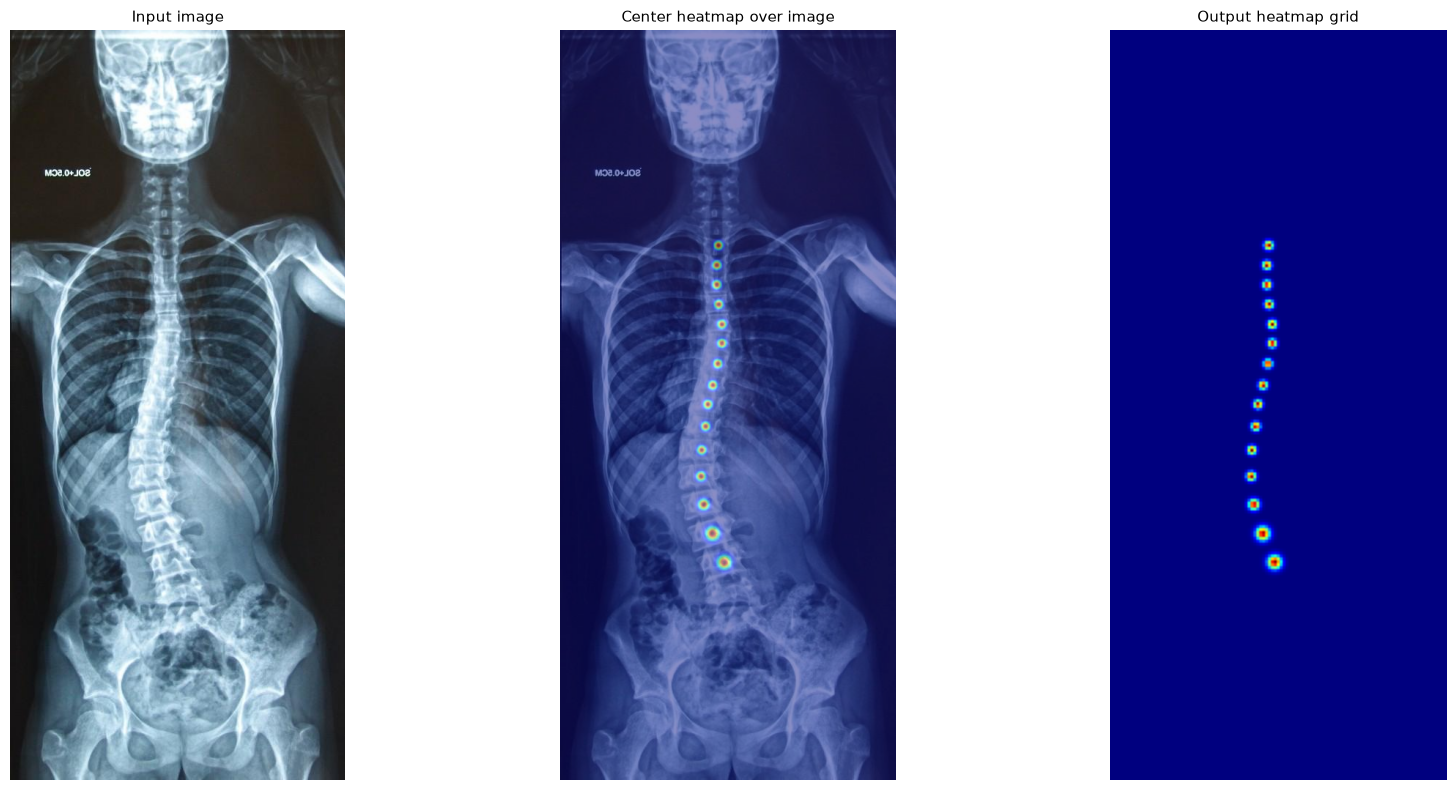

saved: c:\Users\gcpup\Desktop\Workspaces\AI\Spine-Opportunistic-Screening\outputs\center_heatmap_preview\coco_no_buu_train_000_center_heatmap.png


In [23]:
POLY_ORDER = [0, 1, 3, 2, 0]
KPT_COLORS = ["red", "yellow", "white", "lime"]


def draw_polygon(ax, points, color="lime", linewidth=1.5, alpha=1.0):
    closed = points[POLY_ORDER]
    ax.plot(closed[:, 0], closed[:, 1], color=color, linewidth=linewidth, alpha=alpha)
    for idx, point in enumerate(points):
        ax.scatter([point[0]], [point[1]], s=18, color=KPT_COLORS[idx], edgecolor="black", linewidth=0.3, alpha=alpha)


def reconstruct_from_targets(record, targets, down_ratio=4):
    ix, iy = record["grid_xy"]
    center_out = np.array([ix, iy], dtype=np.float32) + targets["reg"][:, iy, ix]
    offsets = targets["wh"][:, iy, ix].reshape(4, 2)
    corners_out = center_out[None, :] - offsets
    return center_out * down_ratio, corners_out * down_ratio


def draw_target_overlay(ax, image_rgb, targets, title=None, show_heatmap=True, show_corners=False):
    ax.imshow(image_rgb)

    if show_heatmap:
        hm_resized = cv2.resize(targets["hm"], (image_rgb.shape[1], image_rgb.shape[0]), interpolation=cv2.INTER_CUBIC)
        ax.imshow(hm_resized, cmap="jet", alpha=0.42, vmin=0, vmax=1)

    if show_corners:
        for record in targets["records"]:
            draw_polygon(ax, record["points_px"], color="cyan", linewidth=0.9, alpha=0.9)
            center = record["center_px"]
            ax.scatter([center[0]], [center[1]], s=18, color="magenta", edgecolor="black", linewidth=0.3)

    if title:
        ax.set_title(title)
    ax.axis("off")


def make_sample_title(index, image_info, targets):
    source = image_info.get("source_dataset", "unknown")
    name = Path(image_info["file_name"]).stem
    return f"{index}: {source}\n{name} | n={len(targets['records'])} | col={targets['collisions']}"


fig, axes = plt.subplots(1, 3, figsize=(18, 8))

axes[0].imshow(image_rgb)
axes[0].set_title("Input image")
axes[0].axis("off")

hm_resized = cv2.resize(targets["hm"], (image_rgb.shape[1], image_rgb.shape[0]), interpolation=cv2.INTER_CUBIC)
axes[1].imshow(image_rgb)
axes[1].imshow(hm_resized, cmap="jet", alpha=0.45, vmin=0, vmax=1)
axes[1].set_title("Center heatmap over image")
axes[1].axis("off")

axes[2].imshow(targets["hm"], cmap="jet", vmin=0, vmax=1)
axes[2].set_title("Output heatmap grid")
axes[2].axis("off")

fig.tight_layout()
preview_path = OUTPUT_DIR / f"{DATASET_NAME}_{SPLIT}_{SAMPLE_INDEX:03d}_center_heatmap.png"
fig.savefig(preview_path, dpi=160, bbox_inches="tight")
plt.show()
print("saved:", preview_path)


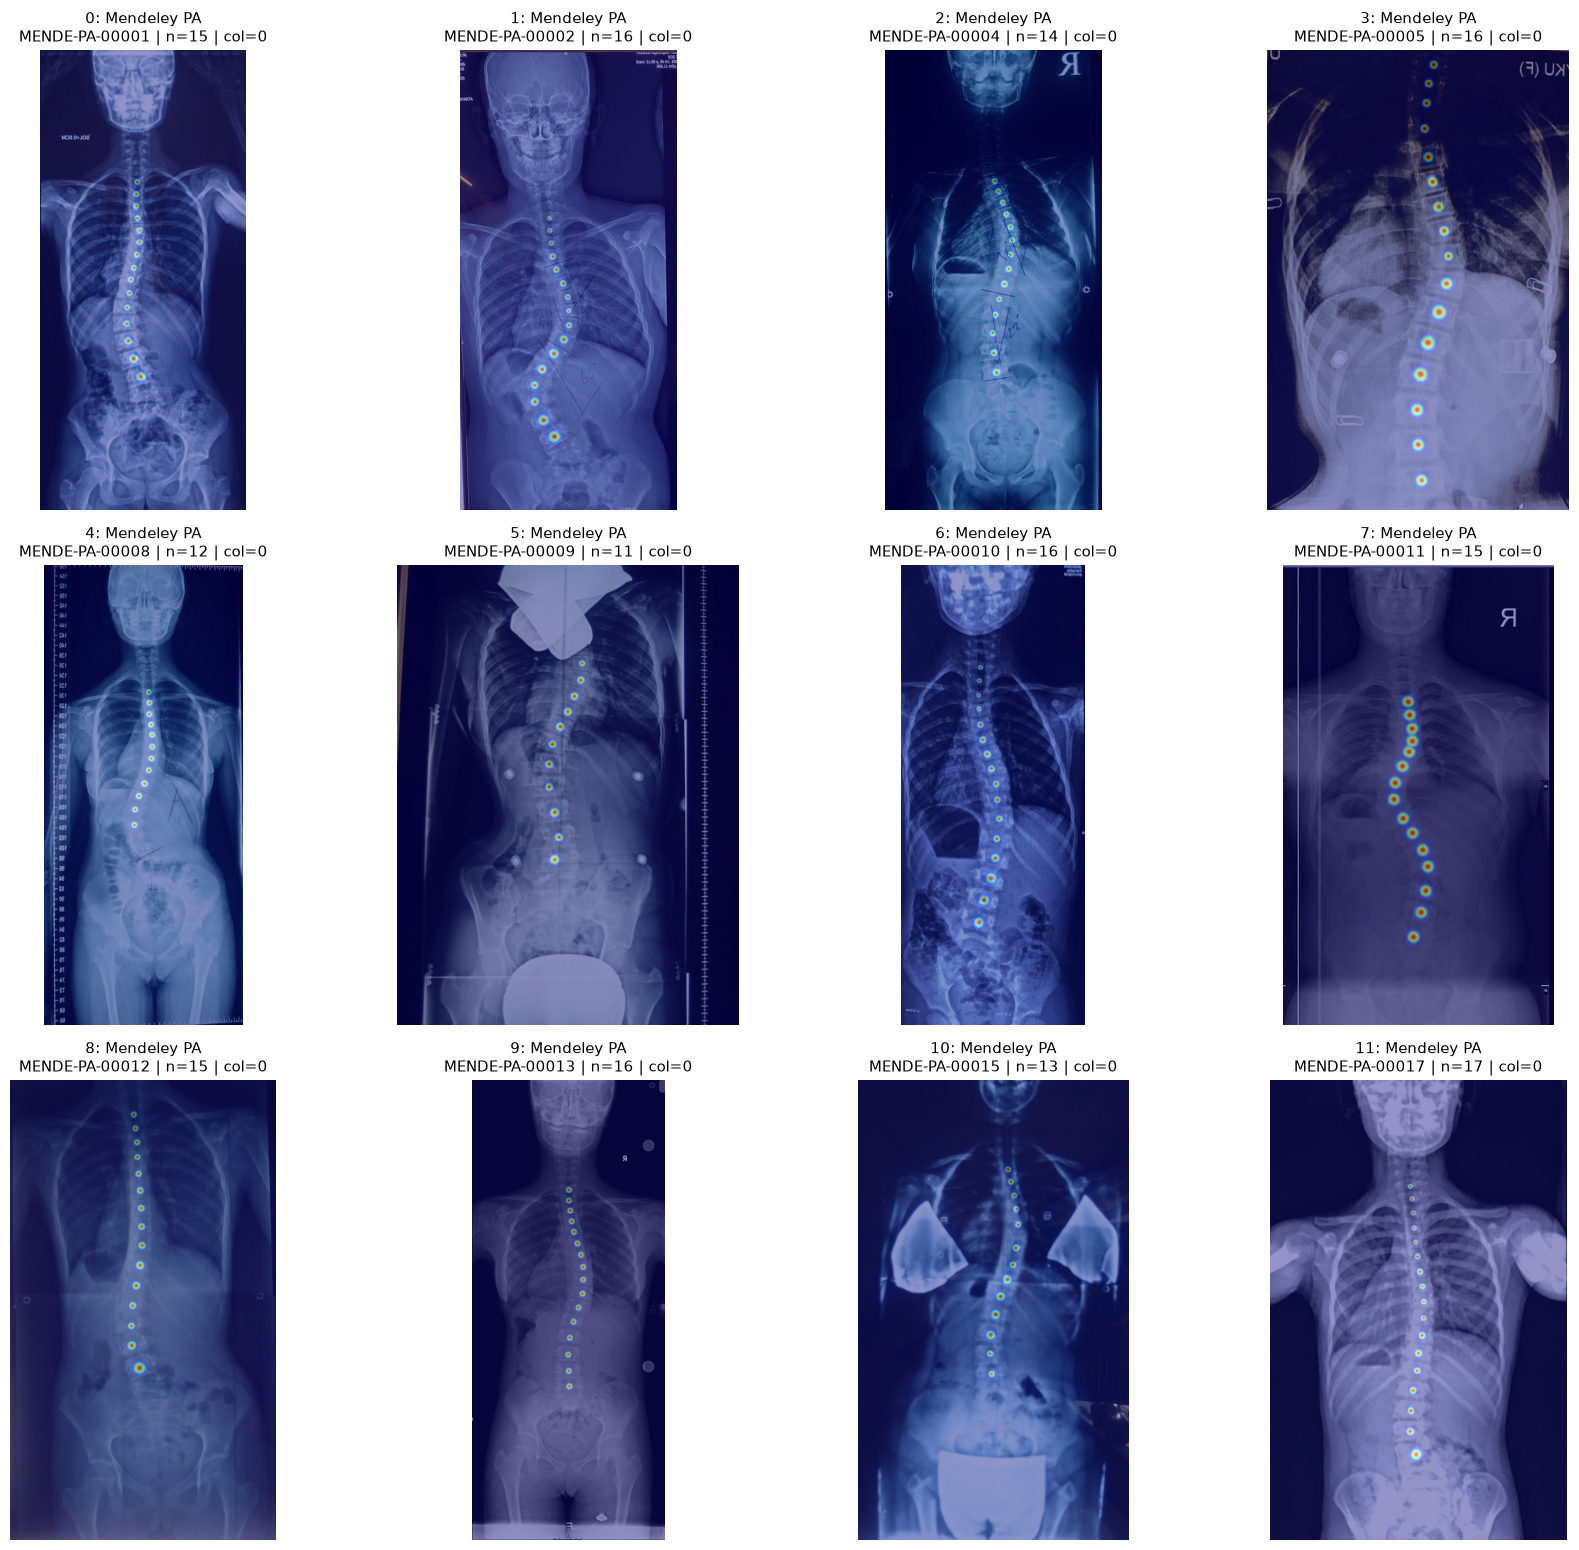

saved: c:\Users\gcpup\Desktop\Workspaces\AI\Spine-Opportunistic-Screening\outputs\center_heatmap_preview\coco_no_buu_train_batch_000_011.png


[{'index': 0,
  'file_name': 'images/mendeley_pa/MENDE-PA-00001.jpg',
  'source': 'Mendeley PA',
  'annotations': 15,
  'target_records': 15,
  'collisions': 0,
  'heatmap_max': 0.9962},
 {'index': 1,
  'file_name': 'images/mendeley_pa/MENDE-PA-00002.jpg',
  'source': 'Mendeley PA',
  'annotations': 16,
  'target_records': 16,
  'collisions': 0,
  'heatmap_max': 0.9998},
 {'index': 2,
  'file_name': 'images/mendeley_pa/MENDE-PA-00004.jpg',
  'source': 'Mendeley PA',
  'annotations': 14,
  'target_records': 14,
  'collisions': 0,
  'heatmap_max': 0.9891},
 {'index': 3,
  'file_name': 'images/mendeley_pa/MENDE-PA-00005.jpg',
  'source': 'Mendeley PA',
  'annotations': 16,
  'target_records': 16,
  'collisions': 0,
  'heatmap_max': 0.9979},
 {'index': 4,
  'file_name': 'images/mendeley_pa/MENDE-PA-00008.jpg',
  'source': 'Mendeley PA',
  'annotations': 12,
  'target_records': 12,
  'collisions': 0,
  'heatmap_max': 0.9808},
 {'index': 5,
  'file_name': 'images/mendeley_pa/MENDE-PA-00009.j

In [24]:
preview_indices = list(range(PREVIEW_START, min(PREVIEW_START + PREVIEW_COUNT, len(images_with_annotations))))
rows = int(math.ceil(len(preview_indices) / PREVIEW_COLS))
fig, axes = plt.subplots(rows, PREVIEW_COLS, figsize=(4.5 * PREVIEW_COLS, 5.2 * rows))
axes = np.atleast_1d(axes).reshape(rows, PREVIEW_COLS)

for ax in axes.ravel():
    ax.axis("off")

batch_stats = []
for ax, image_index in zip(axes.ravel(), preview_indices):
    sample_info, sample_anns, sample_rgb, sample_targets = load_image_and_targets(image_index)
    draw_target_overlay(
        ax,
        sample_rgb,
        sample_targets,
        title=make_sample_title(image_index, sample_info, sample_targets),
        show_heatmap=True,
        show_corners=False,
    )
    batch_stats.append({
        "index": image_index,
        "file_name": sample_info["file_name"],
        "source": sample_info.get("source_dataset"),
        "annotations": len(sample_anns),
        "target_records": len(sample_targets["records"]),
        "collisions": sample_targets["collisions"],
        "heatmap_max": round(float(sample_targets["hm"].max()), 4),
    })

fig.tight_layout()
batch_path = OUTPUT_DIR / f"{DATASET_NAME}_{SPLIT}_batch_{PREVIEW_START:03d}_{preview_indices[-1]:03d}.png"
fig.savefig(batch_path, dpi=150, bbox_inches="tight")
plt.show()
print("saved:", batch_path)
batch_stats


In [25]:
if SHOW_DEBUG_CORNERS:
    fig, ax = plt.subplots(figsize=(10, 12))
    ax.imshow(image_rgb)
    ax.set_title("Reconstructed corners from center + wh target")
    ax.axis("off")

    for record in targets["records"]:
        draw_polygon(ax, record["points_px"], color="white", linewidth=1.0, alpha=0.65)
        center_px, recon_corners_px = reconstruct_from_targets(record, targets, down_ratio=DOWN_RATIO)
        draw_polygon(ax, recon_corners_px, color="lime", linewidth=1.7, alpha=0.9)
        ax.scatter([center_px[0]], [center_px[1]], s=25, color="magenta", edgecolor="black", linewidth=0.4)

    fig.tight_layout()
    recon_path = OUTPUT_DIR / f"{DATASET_NAME}_{SPLIT}_{SAMPLE_INDEX:03d}_corner_offset_reconstruction.png"
    fig.savefig(recon_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("saved:", recon_path)
else:
    print("corner reconstruction preview skipped; set SHOW_DEBUG_CORNERS = True to enable it")

corner reconstruction preview skipped; set SHOW_DEBUG_CORNERS = True to enable it


In [26]:
rows = []
for rank, record in enumerate(targets["records"], start=1):
    ix, iy = record["grid_xy"]
    reg_xy = targets["reg"][:, iy, ix]
    wh_xy = targets["wh"][:, iy, ix]
    rows.append({
        "rank": rank,
        "ann_id": record["annotation_id"],
        "center_px_x": round(float(record["center_px"][0]), 2),
        "center_px_y": round(float(record["center_px"][1]), 2),
        "grid_x": int(ix),
        "grid_y": int(iy),
        "reg_x": round(float(reg_xy[0]), 4),
        "reg_y": round(float(reg_xy[1]), 4),
        "sigma": round(float(record["sigma"]), 3),
        "wh_min": round(float(wh_xy.min()), 3),
        "wh_max": round(float(wh_xy.max()), 3),
    })

rows[:10]

[{'rank': 1,
  'ann_id': 2001,
  'center_px_x': 214.87,
  'center_px_y': 292.05,
  'grid_x': 53,
  'grid_y': 73,
  'reg_x': 0.7182,
  'reg_y': 0.0121,
  'sigma': 1.0,
  'wh_min': -4.967,
  'wh_max': 4.894},
 {'rank': 2,
  'ann_id': 2002,
  'center_px_x': 212.67,
  'center_px_y': 319.13,
  'grid_x': 53,
  'grid_y': 79,
  'reg_x': 0.1664,
  'reg_y': 0.7823,
  'sigma': 1.0,
  'wh_min': -4.636,
  'wh_max': 4.636},
 {'rank': 3,
  'ann_id': 2003,
  'center_px_x': 212.67,
  'center_px_y': 345.82,
  'grid_x': 53,
  'grid_y': 86,
  'reg_x': 0.1663,
  'reg_y': 0.4544,
  'sigma': 1.0,
  'wh_min': -4.636,
  'wh_max': 4.489},
 {'rank': 4,
  'ann_id': 2004,
  'center_px_x': 215.31,
  'center_px_y': 372.75,
  'grid_x': 53,
  'grid_y': 93,
  'reg_x': 0.8287,
  'reg_y': 0.1877,
  'sigma': 1.0,
  'wh_min': -5.004,
  'wh_max': 4.71},
 {'rank': 5,
  'ann_id': 2005,
  'center_px_x': 219.73,
  'center_px_y': 399.78,
  'grid_x': 54,
  'grid_y': 99,
  'reg_x': 0.9324,
  'reg_y': 0.9456,
  'sigma': 1.0,
  'wh_

## Notes

- Use a low peak threshold at inference to collect candidates with high recall.
- Final vertebra count should come from dynamic spine-chain post-processing, not directly from the number of heatmap peaks.
- This preview uses `corner = center - wh_offset`, matching the existing CenterNet-style decoder idea from `best-ai-award-2025`.